In [107]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [108]:
# Create center 
centers = [[1, 1], [-1, -1], [1, -1]]

In [109]:
# Create dataset sample
X, labels_true = make_blobs(n_samples=800, centers=centers, cluster_std=.4, random_state=8)

In [110]:
# Data normalization
X = StandardScaler().fit_transform(X)

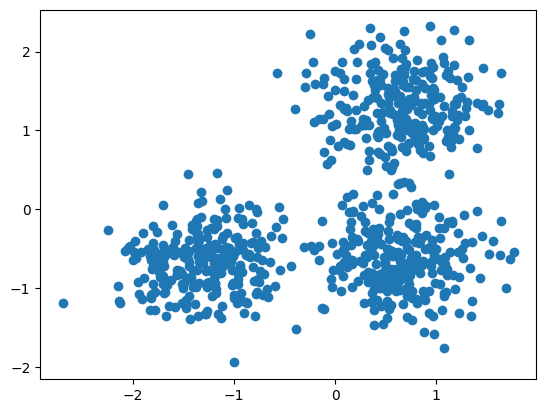

In [111]:
# Data Visualization
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.show() 

## DBSCAN Model

In [112]:
from sklearn.cluster import DBSCAN

In [113]:
# Creating a instance of the model
db = DBSCAN(eps=0.25, min_samples=10)

In [114]:
# Train model on data
db.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.25
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",10
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [115]:
# Storing predicted labels or clusters for each sample
labels = db.labels_

In [116]:
# Estimation of the total cluster count

number_cluster = (len(set(labels))) - (1 if -1 in labels else 0)

number_noise = list(labels).count(-1)

print(f"Estimated number of cluster: {number_cluster}")

print(f"Estimated number of noise point: {number_noise}")

Estimated number of cluster: 3
Estimated number of noise point: 36


## Estimate

In [117]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

In [118]:
Homo = homogeneity_score(labels_true, labels)
Comp = completeness_score(labels_true, labels)
V_mea = v_measure_score(labels_true, labels)
Adj_RI = adjusted_rand_score(labels_true, labels)
Adj_MI = adjusted_mutual_info_score(labels_true, labels)
Silho = silhouette_score(X, labels)

In [119]:
print(f"The Homogeneity value evaluation measure is equal to            ={Homo}")
print(f"The Completeness value evaluation measure is equal to           ={Comp}")
print(f"The V_measure value evaluation measure is equal to              ={V_mea}")
print(f"The Adjusted Rand Index value evaluation measure is equal to    ={Adj_RI}")
print(f"The Adjusted Mutual Info value evaluation measure is equal to   ={Adj_MI}")
print(f"The Silhouette value evaluation measure is equal to             ={Silho}")

The Homogeneity value evaluation measure is equal to            =0.910534444296311
The Completeness value evaluation measure is equal to           =0.8115125331624884
The V_measure value evaluation measure is equal to              =0.8581764877436704
The Adjusted Rand Index value evaluation measure is equal to    =0.9057447719422569
The Adjusted Mutual Info value evaluation measure is equal to   =0.8577146394073376
The Silhouette value evaluation measure is equal to             =0.5840844745367634


## Result

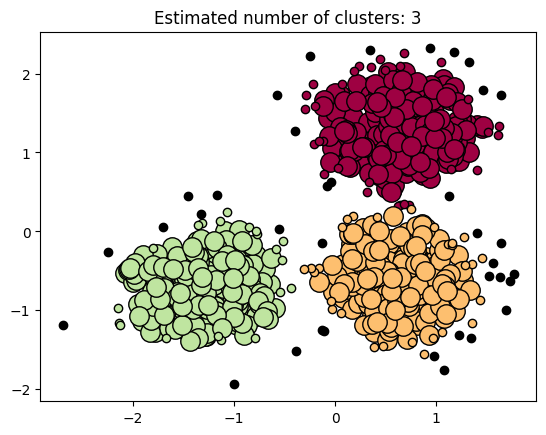

In [120]:
import numpy as np
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {number_cluster}")
plt.show()